In [3]:
import os
os.chdir('/Users/ruhil/health-risk-predictor')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')

# First Look
print(df.shape)
df.head()
print(df.info())
print(df.describe())

(253680, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  

In [4]:
print(df['Diabetes_012'].value_counts())
print(df['Diabetes_012'].unique())

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64
[0. 2. 1.]


In [5]:
print(df['Diabetes_012'].value_counts())


Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64


In [6]:
df['Diabetes_binary'] = df['Diabetes_012'].apply(lambda x:0 if x ==0 else 1)

In [7]:
df['Diabetes_binary'].value_counts()

Diabetes_binary
0    213703
1     39977
Name: count, dtype: int64

In [8]:
correlation = df.corr()['Diabetes_binary'].sort_values(ascending=False)
correlation

Diabetes_binary         1.000000
Diabetes_012            0.983304
GenHlth                 0.300785
HighBP                  0.270334
BMI                     0.223851
DiffWalk                0.222155
HighChol                0.210290
Age                     0.185891
HeartDiseaseorAttack    0.176933
PhysHlth                0.174948
Stroke                  0.104800
MentHlth                0.074971
CholCheck               0.067879
Smoker                  0.062778
NoDocbcCost             0.038025
Sex                     0.029606
AnyHealthcare           0.014079
Fruits                 -0.042088
HvyAlcoholConsump      -0.056682
Veggies                -0.059219
PhysActivity           -0.121392
Education              -0.131803
Income                 -0.172794
Name: Diabetes_binary, dtype: float64

/var/folders/3l/1_q7gwgn3ql9_hjs9p1byk280000gn/T/ipykernel_28162/1259011892.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diabetes_binary',data = df, palette='Set2')


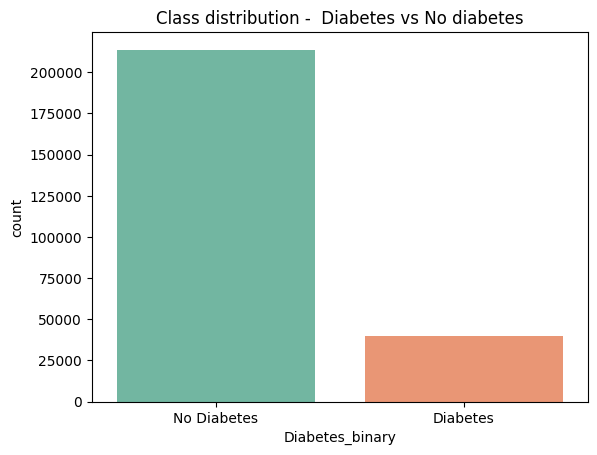

/var/folders/3l/1_q7gwgn3ql9_hjs9p1byk280000gn/T/ipykernel_28162/1259011892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x ='Diabetes_binary', y='BMI',data =df, palette='coolwarm')


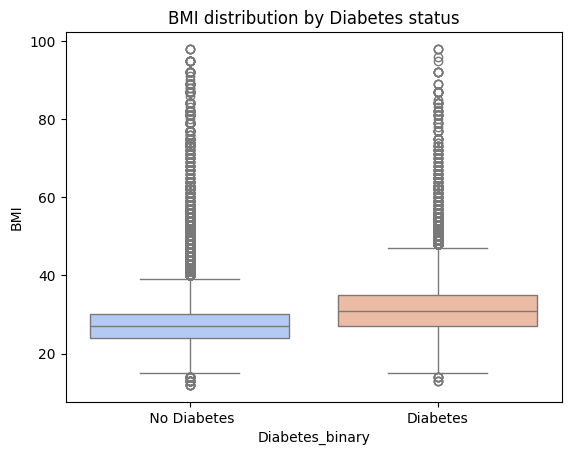

In [9]:
# Plot 1 Class Imbalance
plt.Figure(figsize=(8,5))
sns.countplot(x='Diabetes_binary',data = df, palette='Set2')
plt.title('Class distribution -  Diabetes vs No diabetes')
plt.xticks([0,1],['No Diabetes','Diabetes'])
plt.savefig('class_distribution.png')
plt.show()

# Plot 2 - BMI vs Diabetes

plt.Figure(figsize=(8,5))
sns.boxplot(x ='Diabetes_binary', y='BMI',data =df, palette='coolwarm')
plt.title('BMI distribution by Diabetes status')
plt.xticks([0,1],[' No Diabetes','Diabetes'])
plt.savefig('bmi_daibetes.png')
plt.show()

In [10]:
# Model Training
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# define Features and target 
X = df.drop(['Diabetes_binary','Diabetes_012'], axis =1)
y = df['Diabetes_binary']

# Split first Before aplying SMOTE
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2 , random_state=42)

# Applying SMOTE on training data
smote = SMOTE(random_state=42)
X_train_sm,y_train_sm = smote.fit_resample(X_train,y_train)

# Check balance after SMOTE
print("Before Smote",y_train.value_counts())
print("After Smote",y_train_sm.value_counts())

Before Smote Diabetes_binary
0    170908
1     32036
Name: count, dtype: int64
After Smote Diabetes_binary
0    170908
1    170908
Name: count, dtype: int64


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


# Train Model
model = LogisticRegression(max_iter = 1000, random_state=42)
model.fit(X_train_sm,y_train_sm)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate
print(classification_report(y_test,y_pred))
print("ROC AUC Score",roc_auc_score(y_test,model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.94      0.72      0.82     42795
           1       0.34      0.77      0.47      7941

    accuracy                           0.73     50736
   macro avg       0.64      0.74      0.64     50736
weighted avg       0.85      0.73      0.76     50736

ROC AUC Score 0.8196610859158027


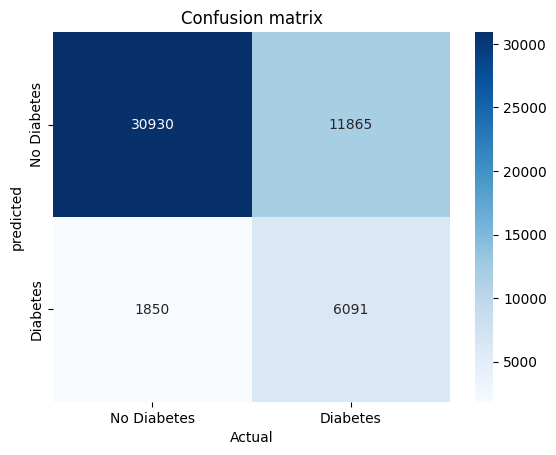

In [12]:
# Confusion Matrix
plt.Figure(figsize=(8,5))
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues', xticklabels=['No Diabetes','Diabetes'],yticklabels=['No Diabetes','Diabetes'])
plt.title('Confusion matrix')
plt.xlabel('Actual')
plt.ylabel('predicted')
plt.savefig('Confusion_matrix.png')
plt.show()

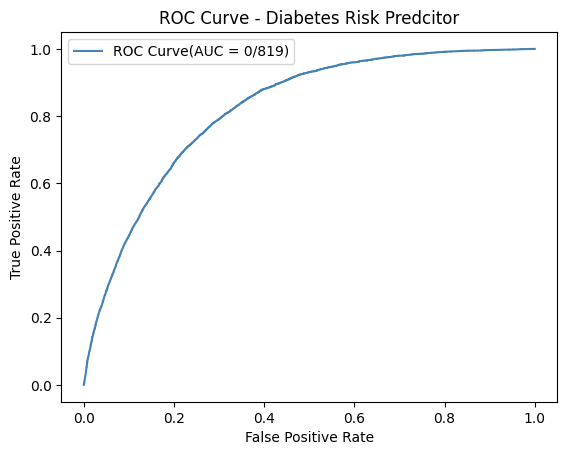

In [13]:
from sklearn.metrics import roc_curve

# ROC Curve

fpr,tpr,thresholds = roc_curve(y_test,model.predict_proba(X_test)[:,1])
plt.Figure(figsize=(8,5))
plt.plot(fpr,tpr,color ='steelblue',label= 'ROC Curve(AUC = 0/819)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Diabetes Risk Predcitor')
plt.legend()
plt.savefig('roc_curve.png')
plt.show()

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# use a sample to keep it fast
X_sample = X_train_sm.sample(n = 10000 , random_state=42)
y_sample = y_train_sm[X_sample.index]

# 5 Fold Cross Validation
model = LogisticRegression(max_iter=1000, random_state=42)
scores = cross_val_score(model, X_sample, y_sample, cv=5, scoring='roc_auc')

print("AUC per fold", scores.round(3))
print("Mean AUC",scores.mean().round(3))
print("Std. Deviation",scores.std().round(3))


AUC per fold [0.836 0.823 0.843 0.822 0.84 ]
Mean AUC 0.833
Std. Deviation 0.009


In [15]:
# Feature Engineering 
df['BMI_Age'] = df['BMI']*df['Age']
df['BMI_BP'] = df['BMI']*df['HighBP']


# Check new Features

print(df[['BMI','HighBP','Age','BMI_Age','BMI_BP']].head())

    BMI  HighBP   Age  BMI_Age  BMI_BP
0  40.0     1.0   9.0    360.0    40.0
1  25.0     0.0   7.0    175.0     0.0
2  28.0     1.0   9.0    252.0    28.0
3  27.0     1.0  11.0    297.0    27.0
4  24.0     1.0  11.0    264.0    24.0


In [16]:
# New Feature set with engineered features
X_new = df.drop(['Diabetes_binary','Diabetes_012'],axis=1)

# Split and SMOTE
X_train_new ,X_test_new ,y_train_new,y_test_new = train_test_split(X_new,y,test_size=0.2,random_state=42)

X_sample_new = X_train_new.sample(n=50000,random_state =42)
y_sample_new = y_train_new[X_sample_new.index]

smote = SMOTE(random_state=42)
X_train_fe, y_train_fe = smote.fit_resample(X_sample_new,y_sample_new)

# Cross Validate

scores_new = cross_val_score(LogisticRegression(max_iter=1000,random_state=42),X_train_fe,y_train_fe,cv =5, scoring='roc_auc')

print("Old Mean AUC:",0.833)
print("New Mean AUC:", scores_new.mean().round(3))
print("Improvement:",(scores_new.mean()-0.833).round(3))

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

Old Mean AUC: 0.833
New Mean AUC: 0.823
Improvement: -0.01


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# Defining Models
models = {'Logistic Regression':LogisticRegression(max_iter=1000,random_state=42),'Random Forest':RandomForestClassifier(n_estimators=100,random_state=42)
          ,'XGBoost':XGBClassifier(random_state=42, eval_metric = 'logloss')}

# Compare using Cross Validation

results={}
for name, model in models.items():
    scores = cross_val_score(model,X_train_fe,y_train_fe,cv =5 , scoring = 'roc_auc')
    results[name] = scores.mean().round(3)
    print(f"{name}:{scores.mean().round(3)} (+/-{scores.std().round(3)})")

# Winner    
best_model = max(results, key=results.get)
print(f"\nBest MOdel:{best_model} with AUC:{results[best_model]}")

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

Logistic Regression:0.823 (+/-0.002)
Random Forest:0.975 (+/-0.05)
XGBoost:0.948 (+/-0.102)

Best MOdel:Random Forest with AUC:0.975


In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define Hyperparameter grid
param_grid = {
               'C':[0.01,0.1,1,10,100],
               'max_iter':[100,500,1000],
               'solver':['lbfgs','liblinear']

}

# Grid SearchCV
grid_search = GridSearchCV(LogisticRegression(random_state=42),param_grid,cv=5,scoring='roc_auc',n_jobs=-1,verbose=1)

grid_search.fit(X_train_fe,y_train_fe)

print("Best parameters:",grid_search.best_params_)
print("Best AUC:",grid_search.best_score_.round(3))

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also re

Best parameters: {'C': 0.1, 'max_iter': 100, 'solver': 'liblinear'}
Best AUC: 0.823


In [21]:
# Train final model with best Parametres
best_model = grid_search.best_estimator_
# Adding engineered featured to test set 
X_test['BMI_Age'] = X_test['BMI']*X_test['Age']
X_test['BMI_BP'] = X_test['BMI']*X_test['HighBP']

# predict on test data
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:,1]

# Evaluate
from sklearn.metrics import classification_report,roc_auc_score
print(classification_report(y_test,y_pred))
print("Final ROC AUC:",roc_auc_score(y_test,y_pred_proba))


              precision    recall  f1-score   support

           0       0.94      0.73      0.82     42795
           1       0.34      0.76      0.47      7941

    accuracy                           0.73     50736
   macro avg       0.64      0.75      0.65     50736
weighted avg       0.85      0.73      0.77     50736

Final ROC AUC: 0.8219635276338955
